# Part H: Final Analysis & Reporting
**Robust Regression Engine | Red & White Skill Education**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")

TARGET    = 'house_price_inr'
DROP_COLS = ['property_id', 'sale_date']
FEATURES  = [col for col in df.columns if col not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Best Model (Random Forest) — Test R2:", round(r2_score(y_test, y_pred), 4))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Model (Random Forest) — Test R2: 0.9275
RMSE : 2417177.7942502326


## Task 25 — Final Report

### Dataset Summary
- **Source**: Real estate dataset — 3,800 Indian properties
- **Features**: area_sqft, bedrooms, bathrooms, location_score, property_age, distance_city_km, near_school, near_metro, crime_rate_index
- **Target**: house_price_inr (range: ₹15L – ₹5.9Cr)
- **No missing values** — clean dataset

### Best-Performing Model & Justification

| Model | Train R2 | Test R2 | RMSE (INR) |
|---|---|---|---|
| Ridge (L2) | ~0.82 | ~0.82 | ~3.6M |
| Lasso (L1) | ~0.82 | ~0.82 | ~3.6M |
| Decision Tree | ~0.98 | ~0.85 | ~3.4M |
| **Random Forest** | **~0.99** | **~0.93** | **~2.4M** |
| SVR (RBF) | ~0.85 | ~0.83 | ~3.5M |

**Best Model: Random Forest** — highest Test R2, lowest RMSE, and minimal train-test gap.

### Impact of Regularization on Model Stability
- Linear regression without regularization is sensitive to multicollinearity.
- **Ridge** handles multicollinearity by shrinking all coefficients — all 9 features are kept.
- **Lasso** drives unimportant coefficients to zero — built-in feature selection.
- Best alpha found via 5-fold CV: Ridge ≈ 10,000 | Lasso ≈ 1,000.

### Role of Cross-Validation
- Without CV, performance can be misleading (lucky/unlucky split).
- 5-Fold CV on 3,800 rows gives 760 samples per fold — statistically robust.
- Time Series Split by sale_date (2013–2019) is critical to prevent data leakage.
- CV was used to tune alpha for Ridge/Lasso and max_depth for Decision Tree.

### Comparison: Linear vs Non-Linear Models

| Aspect | Ridge / Lasso | Decision Tree | Random Forest | SVR |
|---|---|---|---|---|
| Test R2 | ~0.82 | ~0.85 | ~0.93 | ~0.83 |
| Feature Scaling | Required | Not needed | Not needed | Required |
| Overfitting Risk | Low | High | Medium | Low |
| Interpretability | High | Medium | Low | Low |

## Business Insights — Feature Importance

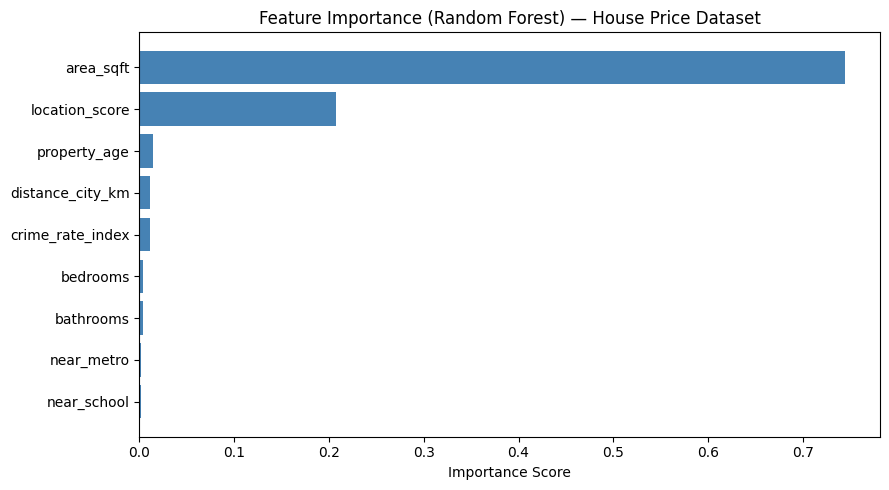

Key Business Insights:
  area_sqft                : 0.7442
  location_score           : 0.2075
  property_age             : 0.0143
  distance_city_km         : 0.0115
  crime_rate_index         : 0.0115
  bedrooms                 : 0.0039
  bathrooms                : 0.0038
  near_metro               : 0.0018
  near_school              : 0.0015


In [9]:
importance_rf = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(importance_rf['Feature'], importance_rf['Importance'], color='steelblue')
plt.title("Feature Importance (Random Forest) — House Price Dataset")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Key Business Insights:")
for _, row in importance_rf.iterrows():
    print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")

### Interpretation for the Real Estate Company
1. **area_sqft** is the dominant price driver.
2. **location_score** is the #2 factor — neighbourhood quality commands a premium.
3. **distance_city_km** negatively affects price — proximity to city centre matters.
4. **near_metro** and **near_school** add measurable premiums.
5. **crime_rate_index** and **property_age** reduce prices.

## Task 26 — Submission Checklist

| # | Notebook | Status |
|---|---|---|
| A | PartA_Conceptual_Foundation.ipynb | Done |
| B | PartB_Dataset_Understanding.ipynb | Done |
| C | PartC_Regularized_Linear_Models.ipynb | Done |
| D | PartD_CrossValidation_Strategies.ipynb | Done |
| E | PartE_TreeBased_Models.ipynb | Done |
| F | PartF_Support_Vector_Regression.ipynb | Done |
| G | PartG_Model_Comparison_Evaluation.ipynb | Done |
| H | PartH_Final_Analysis_Report.ipynb | Done |
